# Project 10 -- Anthony Micco

**TA Help:** N/A

**Collaboration:** N/A

**Internet Resources:** N/A

**ChatGPT, Gemini, Claude, etc:** N/A

**Link to AI Chat History**: None

**OVERALL MESSAGE:** Any time that you used anything except your brain to solve the questions in these projects, you need to disclose such resources at the start of the project, with details about your usage of the tools.

**YOUR OWN WORK:** Even when you utilize other resources, do NOT just copy and paste.  Write all explanations in your own words, using several sentences in English, which are understandable and which you wrote (and did not just copy and paste).

## Question 1

In [2]:
#imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
#reading in the data
spotify_df = pd.read_csv("/anvil/projects/tdm/data/spotify/linear_regression_popularity.csv")

spotify_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 37 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Unnamed: 0.1                1500 non-null   int64  
 1   Unnamed: 0                  1500 non-null   int64  
 2   track_id                    1500 non-null   object 
 3   track_name                  1500 non-null   object 
 4   popularity                  1500 non-null   int64  
 5   available_markets           1500 non-null   object 
 6   disc_number                 1500 non-null   int64  
 7   duration_ms                 1500 non-null   int64  
 8   explicit                    1500 non-null   bool   
 9   track_number                1500 non-null   int64  
 10  href                        1500 non-null   object 
 11  album_id                    1500 non-null   object 
 12  album_name                  1500 non-null   object 
 13  album_release_date          1500 

In [4]:
#dropping unnecessary columns
drop_cols = [
    "Unnamed: 0", "Unnamed: 0.1", "track_id", "track_name", "available_markets", "href",
    "album_id", "album_name", "album_release_date", "album_type",
    "artists_names", "artists_ids", "principal_artist_id",
    "principal_artist_name", "artist_genres", "analysis_url", "duration_min", "principal_artist_followers"]

spotify_df.drop(columns=drop_cols, inplace=True)

In [5]:
spotify_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 19 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   popularity          1500 non-null   int64  
 1   disc_number         1500 non-null   int64  
 2   duration_ms         1500 non-null   int64  
 3   explicit            1500 non-null   bool   
 4   track_number        1500 non-null   int64  
 5   album_total_tracks  1500 non-null   int64  
 6   acousticness        1500 non-null   float64
 7   danceability        1500 non-null   float64
 8   energy              1500 non-null   float64
 9   instrumentalness    1500 non-null   float64
 10  key                 1500 non-null   float64
 11  liveness            1500 non-null   float64
 12  loudness            1500 non-null   float64
 13  mode                1500 non-null   float64
 14  speechiness         1500 non-null   float64
 15  tempo               1500 non-null   float64
 16  time_s

In [6]:
#separating the target variable from the predictor variables
y = spotify_df["popularity"].copy()
X = spotify_df.drop(columns=["popularity"]).copy()

In [7]:
X.head()

,disc_number,duration_ms,explicit,track_number,album_total_tracks,acousticness,danceability,energy,instrumentalness,key,liveness,loudness,mode,speechiness,tempo,time_signature,valence,year
0,1,355400,False,9,14,0.271000,0.397,0.386,0.000000,0.0,0.1880,-10.405,0.0,0.0503,144.242,4.0,0.210,2006
1,1,230549,False,2,12,0.534000,0.571,0.438,0.000016,2.0,0.1870,-7.007,1.0,0.0279,145.948,4.0,0.444,2002
2,1,115413,False,1,12,0.000179,0.223,0.805,0.814000,8.0,0.0849,-8.969,1.0,0.0370,168.165,4.0,0.250,2015
3,1,236946,False,1,12,0.005490,0.551,0.591,0.000007,6.0,0.0416,-8.404,0.0,0.1200,201.810,4.0,0.474,1991
4,1,195613,False,3,12,0.286000,0.806,0.508,0.000000,11.0,0.0943,-9.729,0.0,0.0966,109.957,4.0,0.820,2001


In [8]:
y.head()

0    67
1    70
2    75
3    65
4    69
Name: popularity, dtype: int64

In [9]:
#splitting the data into testing and training sets
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

1b) The target variable is isolated from the predictor variables because because the target variable is the value we are trying to predict from the predictor values. If we include the target variable, then it will influence the model and essentially make the machine learning model pointless because it already knows the answer it is trying to predict. 

1c) The data is split into training and testing sets because we want the model to identify and learn patterns within the data using the training set, and then validate the model's performance using the test data. Since the model has not seen this data yet, it will give us an idea of how well it performs when using unknown data. 

## Question 2

In [10]:
# fitting a simple linear regression
from sklearn.linear_model import LinearRegression

#fit the linear regression 
lr = LinearRegression()
lr.fit(X_train, y_train)

#evaluate performance
train_score = lr.score(X_train, y_train)
test_score = lr.score(X_test, y_test)

print(f"Training R^2: {train_score}")
print(f"Test R^2: {test_score}")

Training R^2: 0.4498996746098677
Test R^2: 0.44152177295357964


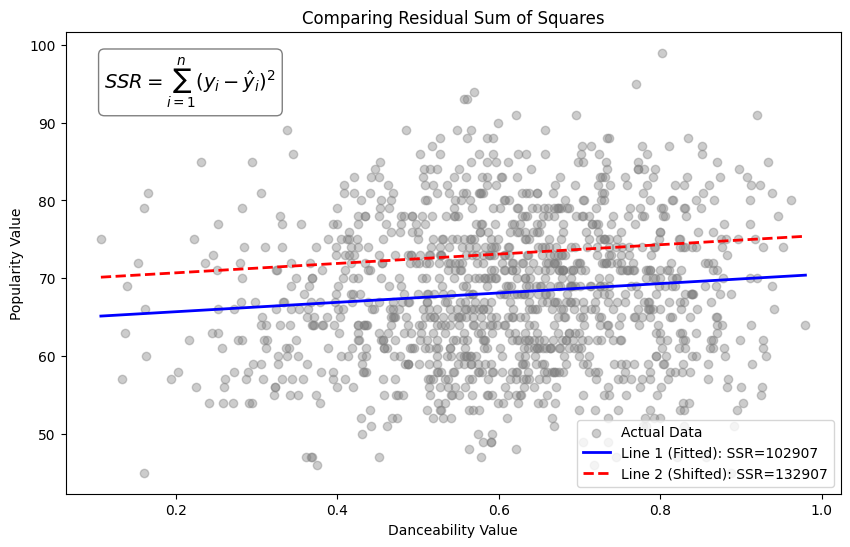

In [11]:
#fitting a linear regression using only the danceability feature
import warnings
warnings.filterwarnings("ignore")

#fit the simple linear regression
X_dance = X_train[["danceability"]]
lr = LinearRegression().fit(X_dance, y_train)
x_line = np.linspace(X_dance.min()[0], X_dance.max()[0], 100)
y_line_1 = lr.predict(x_line.reshape(-1,1))
y_line_2 = y_line_1 + 5

ssr_1 = np.sum((y_train - lr.predict(X_dance))**2)
ssr_2 = np.sum((y_train - (lr.predict(X_dance)+5))**2)

plt.figure(figsize=(10,6))
plt.scatter(X_dance, y_train, alpha=0.4, label="Actual Data", color="gray")

#plotting the lines
plt.plot(x_line, y_line_1, color="blue", linewidth=2, label=f"Line 1 (Fitted): SSR={ssr_1:.0f}")
plt.plot(x_line, y_line_2, "--", color="red", linewidth=2, label=f"Line 2 (Shifted): SSR={ssr_2:.0f}")

# Adding the SSR Equation in a box
ssr_formula = r'$SSR = \sum_{i=1}^{n} (y_i - \hat{y}_i)^2$'
plt.text(0.05, 0.95, ssr_formula, transform=plt.gca().transAxes, fontsize=14,
         verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.5))

plt.title("Comparing Residual Sum of Squares")
plt.xlabel("Danceability Value")
plt.ylabel("Popularity Value") 
plt.legend(loc="lower right")
plt.show()

In [12]:
#fitting a multivariable linear regression 
lr = LinearRegression()
lr.fit(X_train, y_train)

#generate predictions
y_pred = lr.predict(X_test)

#creating the comparison dataframe to see actual value, predicted value, and residuals
comparision_df = pd.DataFrame({
    "Actual (y)":y_test.values,
    "Predicted (ŷ)": y_pred,
    "Residual (y-ŷ)": (y_test.values - y_pred)
})

comparision_df.head()

,Actual (y),Predicted (ŷ),Residual (y-ŷ)
0,79,80.210526,-1.210526
1,56,58.187675,-2.187675
2,69,72.377679,-3.377679
3,69,74.827226,-5.827226
4,89,78.476283,10.523717


In [13]:
#calculating the residual sum of squares
ssr = np.sum(comparision_df["Residual (y-ŷ)"]**2)
print(f"The SSR for this model is: {ssr:.4f}")

The SSR for this model is: 16351.8162


In [14]:
#calculating and displaying the coefficients estimated by the multivariable regression 
print("Intercept (β₀):", round(lr.intercept_, 3))

coeff_df = pd.DataFrame({
    "Feature": X.columns,
    "Estimated Coefficient": lr.coef_
}).round(4)

coeff_df

Intercept (β₀): -1016.041


,Feature,Estimated Coefficient
0,disc_number,-2.2898
1,duration_ms,0.0000
2,explicit,0.1466
3,track_number,-0.0211
4,album_total_tracks,0.0116
5,acousticness,1.0666
6,danceability,2.7971
7,energy,0.1395
8,instrumentalness,-0.7714
9,key,0.0548


2a) $\hat{y}$ represents the predicted value the model comes up with for each row of data in the dataset. It is the sum of the intercept, $\beta_0$ and the coefficients $\beta_1, \cdots \beta_p$ multiplied by each predictor value $x_1, \cdots x_p$. The coefficients serve as a weight for each predictor variable, so each predictor impacts the final prediction in a varying way. 

2b) The fitted line (Line 1) would be selected by the least squares method because it has the lower residual sum of squares value. The least squares method attempts to minimize the residual sum of squares value by selecting coefficient values that can do this, thus since the SSR for Line 1 is less than the SSR for Line 2, the model would select Line 1. 

2c) A residual measures how far off the predicted value was from the actual value observed in the dataset. The residuals are squared instead of summed directly because some of the residual values can be negative, so they would cancel positive residuals out and make the overall SSR value seem lower than it actually is or even negative if each value was not squared when before being summed.  

2d) The coefficient values shown in the table are computed based on the value of the residuals. Linear regression uses the least squares method, meaning it calculates coefficients using the difference from their predicted value to the observed value and whichever ones minimize the overall SSR value, it then assigns as the coefficient for that predictor.  

## Question 3

In [18]:
#performing forward stepwise selection based on the value of the p-values
import statsmodels.api as sm

# Keep only numeric columns and drop missing values
X_num = X_train.select_dtypes(include=[np.number]).dropna()
y_num = pd.to_numeric(y_train, errors="coerce").loc[X_num.index]

#function to calculate and select p-values
def forward_selection_pvalues(X, y, alpha=0.05):
    remaining = list(X.columns)
    selected = []

    while remaining:
        pvals = []

        for feature in remaining:
            X_model = sm.add_constant(X[selected + [feature]].values.astype(float))
            model = sm.OLS(y.values.astype(float), X_model).fit()
            pvals.append((model.pvalues[-1], feature))

        best_pval, best_feature = min(pvals)

        if best_pval < alpha:
            selected.append(best_feature)
            remaining.remove(best_feature)
        else:
            break

    return selected

#printing the selected values
selected_features = forward_selection_pvalues(X_num, y_num)
print("Forward-selected features:")
print(selected_features)

Forward-selected features:
['year', 'mode', 'speechiness']


In [19]:
#fitting a multivariable linear regression and computing the R^2 for the test set
from sklearn.metrics import r2_score

# Full model
lr_full = LinearRegression()
lr_full.fit(X_train, y_train)
y_pred_full = lr_full.predict(X_test)
r2_full = r2_score(y_test, y_pred_full)

# P-value selected model
lr_pval = LinearRegression()
lr_pval.fit(X_train[selected_features], y_train)
y_pred_pval = lr_pval.predict(X_test[selected_features])
r2_pval = r2_score(y_test, y_pred_pval)

# Display results
print("Test-set R^2 comparison")
print("-----------------------")
print(f"Full model R^2:        {r2_full:.3f}")
print(f"P-value model R^2:     {r2_pval:.3f}")

Test-set R^2 comparison
-----------------------
Full model R^2:        0.442
P-value model R^2:     0.443


3a) Forward selection is the process of selecting the most impactful variables for determining the value of a target feature. It starts with an empty list of features and adds features if they cause a large improvement in the model's validation criteria or if the p-value is less than some significance level threshold (usually 0.05). The p-value is used because it measures how likely a coefficient is equal to zero, which is important because if a coefficient were 0, then it would make that predictor useless. If these criteria are matched, then forward selection adds the feature to a list and the model uses them for its predictions. 

3c) By using a simpler model with fewer predictors, we can more easily identify which variables are impactful in the model's prediction, so we can look to modify other parameters of the model. It can also potentially improve the model's performance as we are only using predictors that are relevant in generating a response, whereas in a more complex model with many predictors, some of the predictors may be irrelevant in determining a response and simply cause confusion when trying to identify which predictors to focus on. 

## Question 4

In [22]:
# scaling the data using the StandardScaler
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.fit_transform(X_test)

X_train = pd.DataFrame(X_train, columns=X.columns, index=y_train.index)
X_test = pd.DataFrame(X_test, columns=X.columns, index=y_test.index)

In [23]:
#viewing the scaled datasets
X_train.head()

,disc_number,duration_ms,explicit,track_number,album_total_tracks,acousticness,danceability,energy,instrumentalness,key,liveness,loudness,mode,speechiness,tempo,time_signature,valence,year
382,-0.109764,-0.099194,-0.54525,0.198549,-0.081867,-0.841947,-0.732933,1.457654,-0.275229,1.574037,1.385547,1.042032,0.703133,0.103758,1.218727,0.203328,0.361845,-1.629867
538,-0.109764,-0.413392,-0.54525,0.656298,-0.354378,-0.208567,1.091450,1.423638,-0.225711,-0.102948,-0.223110,0.239179,-1.422206,-0.414914,0.508812,0.203328,1.715958,-0.373823
1493,-0.109764,-0.562858,-0.54525,1.114047,0.190644,-0.678893,-2.036064,-0.797091,-0.280362,0.456047,-0.562154,-0.484840,0.703133,-0.632844,-2.032599,0.203328,-1.541231,-1.001845
1112,-0.109764,-0.349431,-0.54525,0.427423,-0.218122,-0.816118,1.575470,0.048438,-0.278404,-1.500436,-0.389025,0.983763,0.703133,-0.388763,-0.052998,0.203328,1.406911,0.523352
324,-0.109764,0.029855,-0.54525,0.885173,0.326900,-0.600693,-0.360610,1.515966,-0.279971,0.176549,-0.575860,1.374248,0.703133,-0.535865,0.498252,0.203328,-0.467701,-1.270998


In [25]:
X_test.head()

,disc_number,duration_ms,explicit,track_number,album_total_tracks,acousticness,danceability,energy,instrumentalness,key,liveness,loudness,mode,speechiness,tempo,time_signature,valence,year
1116,-0.08737,-0.179936,1.687055,-1.024585,-1.665245,-0.759500,0.449120,-0.149576,-0.243276,1.368009,-0.005608,0.362738,-1.552125,-0.300583,0.938851,0.23042,-1.502743,1.731491
1368,-0.08737,0.233581,-0.592749,0.982765,2.879873,-0.707351,-0.702470,0.540535,-0.249421,-0.279092,0.021694,0.626463,0.644278,-0.660563,0.465541,0.23042,1.320685,-1.625636
422,-0.08737,1.386826,1.687055,-0.773666,0.412524,-0.766628,-0.204121,0.185621,-0.249421,-1.102643,1.687115,-0.368240,0.644278,0.107856,0.387408,0.23042,-1.832563,0.733426
413,-0.08737,-0.135384,-0.592749,-0.522747,0.022942,0.737043,-0.399420,-0.001695,-0.249421,0.544459,-0.381011,0.341890,0.644278,-0.665179,-1.645029,0.23042,-0.616220,1.096359
451,-0.08737,-0.115185,1.687055,-1.024585,0.672245,-0.709227,-0.062698,0.461665,-0.249421,0.818975,-0.517521,0.588416,0.644278,-0.150592,-0.884326,0.23042,-0.334718,1.731491


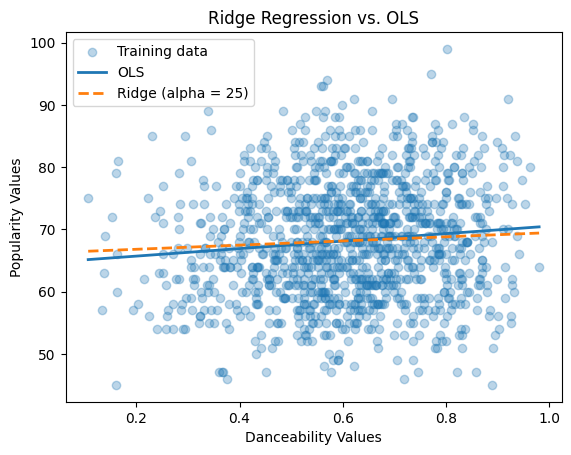

In [28]:
#plotting Ridge Regression vs. Ordinary Least Squares (OLS)
import warnings
from scipy.linalg import LinAlgWarning
from sklearn.linear_model import Ridge

warnings.filterwarnings("ignore", category=LinAlgWarning)

X_train_single = X.loc[X_train.index, ["danceability"]]

# Create grid
x_min = X_train_single["danceability"].min()
x_max = X_train_single["danceability"].max()

x_vals = pd.DataFrame(
    np.linspace(x_min, x_max, 100),
    columns=["danceability"])
# Fit models
ols = LinearRegression()
ols.fit(X_train_single, y_train)
y_ols = ols.predict(x_vals)

ridge = Ridge(alpha=25) # For YOU to fill in
ridge.fit(X_train_single, y_train)
y_ridge = ridge.predict(x_vals)

# Plot
plt.scatter(X_train_single["danceability"], y_train, alpha=0.3, label="Training data")
plt.plot(x_vals["danceability"], y_ols, label="OLS", linewidth=2)
plt.plot(x_vals["danceability"], y_ridge, linestyle="--", label="Ridge (alpha = 25)", linewidth=2) # For YOU to fill in label part

plt.xlabel("Danceability Values")
plt.ylabel("Popularity Values")
plt.title("Ridge Regression vs. OLS")
plt.legend()
plt.show()

In [29]:
#fitting multiple linear and ridge regression models and seeing their coefficients
# Fit OLS model
ols = LinearRegression()
ols.fit(X_train, y_train)

# Fit Ridge model
ridge = Ridge(alpha=25)
ridge.fit(X_train, y_train)

# Compare coefficients
coef_compare = pd.DataFrame({
    "Feature": X_train.columns,
    "OLS Coefficient": ols.coef_,
    "Ridge Coefficient (alpha = 25)": ridge.coef_
}).round(4)

coef_compare

,Feature,OLS Coefficient,Ridge Coefficient (alpha = 25)
0,disc_number,-0.3477,-0.3285
1,duration_ms,0.1885,0.1388
2,explicit,0.0616,0.0978
3,track_number,-0.0920,-0.0926
4,album_total_tracks,0.0853,0.0502
5,acousticness,0.2837,0.2875
6,danceability,0.4508,0.4515
7,energy,0.0287,-0.0051
8,instrumentalness,-0.1307,-0.1189
9,key,0.1960,0.1963


4a) Scaling is important when performing a Ridge Regression because Ridge Regression is trying to reduce the size of coefficients and predictors with larger values will naturally produce larger coefficients. To resolve this, we can scale the data down to ensure the values are smaller and coefficients produced by the Ridge Regression also stay small as well. 

4b) When the $\lambda =0$, the penalty term drops out and Ridge Regression objection is reduced to $\sum_{i=1}^n(y_i-\hat{y_i})^2$ which is the sum of squared residuals equation and so the regression produces the same coefficients as the ordinary least squares method would. 

4c) As $\lambda$ increases, the slope coefficient would need to decrease in order to minimize the overall objective function because the coefficients would naturally increase with the increase in $\lambda$, so we can combat this by reducing the slope coefficient. This behavior can help reduce overfitting because it makes the model less susceptible to noise in the training data.

4d) The Ridge Regression line is much flatter in comparison to the OLS line which makes sense because we are trying to reduce the size of the coefficients as much as possible, so a flatter line signifies a smaller slope (closer to 0). This reflects the effect of regularization because it shows that larger coefficients were penalized and thus being pushed toward 0 to create a flatter slope for the regression line.

4e) For the most part, most of the Ridge Regression coefficients were less than the ordinary least squares coefficients or just slightly larger than them. This shows the idea of coefficient shrinkage because the penalty term shrinks each of the coefficients toward zero, but not every coefficient is shrunk by the same amount based on how closely related they are to the response variable. Therefore, this is why some predictor's coefficients are smaller when fit using Ridge Regression, while others are smaller when using ordinary least squares.  

## Question 5

In [30]:
#fitting three different models and comparing their coefficients
from sklearn.linear_model import Lasso

# Fit models
ols = LinearRegression().fit(X_train, y_train)
ridge = Ridge(alpha=1).fit(X_train, y_train)
lasso = Lasso(alpha=1, max_iter=10000).fit(X_train, y_train)

# Compare coefficients
coef_table = pd.DataFrame({
    "Feature": X_train.columns,
    "OLS": ols.coef_,
    "Ridge (alpha = 1)": ridge.coef_,
    "Lasso (alpha = 1)": lasso.coef_
}).round(4)

coef_table

,Feature,OLS,Ridge (alpha = 1),Lasso (alpha = 1)
0,disc_number,-0.3477,-0.3469,-0.0000
1,duration_ms,0.1885,0.1864,-0.0000
2,explicit,0.0616,0.0631,0.0000
3,track_number,-0.0920,-0.0920,-0.0000
4,album_total_tracks,0.0853,0.0838,-0.0000
5,acousticness,0.2837,0.2839,0.0000
6,danceability,0.4508,0.4508,0.0000
7,energy,0.0287,0.0272,0.0000
8,instrumentalness,-0.1307,-0.1302,-0.0000
9,key,0.1960,0.1960,0.0000


5a) The Lasso Regression objective function is different from the Ridge Regression objective function because Lasso uses the absolute value of the coefficients in the penalty term, while Ridge uses squared coefficients in the penalty term. By squaring the coefficient, it ensures the estimated coefficient never reaches 0 even with large values of $\lambda$, but taking the absolute value of the coefficient with a large $\lambda$ can lead to the estimated coefficients that equal 0.  

5b) The Lasso can force some coefficients to become exactly zero because the $\lambda$ term gets so large that it forces the coefficient to zero and removes that coefficient from the model. This makes Lasso Regression different from Ridge Regression because it can remove irrelevant variables from the model, so only relevant, strongly related variables are used to make the model's prediction and thus makes the features more interpretability and easier to identify. 

5c) The three methods produce widely varying coefficient results, the most drastic is that Lasso produced 17 coefficients with a value of 0, while only 1 had a value greater than 0 and that was "year" with a coefficient of 5.1664. The other two models produced coefficients very similar to each other, with the Ridge Regression producing slightly smaller coefficients because it is intended to reduce the value of the coefficients. The Ridge and Lasso Regressions differ from ordinary least squares because the coefficient's magnitude are forced to be smaller through each of the model's penalty term, so they typically have smaller coefficient magnitudes than ordinary least squares. The most obvious difference between Lasso and Ridge is that Lasso produced coefficients that were equal to 0, while Ridge produced coefficients that were close to 0, but never 0.  

5d) If I were building a model to predict Spotify song popularity using many audio features, but some may be weakly related or irrelevant, I would use Lasso Regression over Ridge Regression for the model because Lasso has the ability to remove those irrelavent and weakly related features using its penalty term. This would result in only the relevant features being present in the model and result in easier interpretability of the model's features. 

## Pledge

By submitting this work I hereby pledge that this is my own, personal work. I've acknowledged in the designated place at the top of this file all sources that I used to complete said work, including but not limited to: online resources, books, and electronic communications. I've noted all collaboration with fellow students and/or TA's. I did not copy or plagiarize another's work.

> As a Boilermaker pursuing academic excellence, I pledge to be honest and true in all that I do. Accountable together – We are Purdue.

https://www.purdue.edu/odos/osrr/honor-pledge/
